# ⌚ Exploratory Data Analysis (EDA) on Flipkart Smartwatches Dataset

## 📖 Project Overview
This project performs **Exploratory Data Analysis (EDA)** on a Flipkart Smartwatches dataset to uncover meaningful insights about smartwatch brands, pricing, ratings, discounts, and customer preferences.

The analysis includes data cleaning, statistical summaries, visualizations, feature engineering, and relationship analysis to understand market trends and product characteristics.

---

## 🎯 Objectives

- Perform data cleaning and preprocessing.
- Analyze smartwatch brands and their market presence.
- Study pricing patterns and discount distribution.
- Examine product ratings and customer reviews.
- Identify relationships between price, ratings, and discounts.
- Generate business insights through data visualization.

---

## 📂 Dataset Features

The dataset contains information such as:

- Brand
- Product Name
- Current Price
- Original Price
- Discount Percentage
- Ratings
- Number of Reviews
- Product Specifications

---

## 📊 Exploratory Analysis Performed

### Data Preprocessing
- Missing value handling
- Duplicate removal
- Data type conversion
- Feature engineering

### Statistical Analysis
- Descriptive Statistics
- GroupBy Analysis
- Cross-tabulation
- Pivot Tables

### Univariate Analysis
- Brand Distribution
- Price Distribution
- Rating Distribution
- Discount Analysis

### Bivariate Analysis
- Price vs Ratings
- Brand vs Price
- Discount vs Ratings
- Correlation Analysis

### Visualizations
- Bar Charts
- Histograms
- Box Plots
- Scatter Plots
- Heatmaps
- Count Plots

---

## 📈 Key Insights

- Identified the most popular smartwatch brands.
- Compared pricing across different brands.
- Analyzed discount strategies adopted by sellers.
- Studied customer rating trends.
- Discovered relationships between pricing, ratings, and discounts.

---

## 🛠 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## 🚀 Outcome

The project demonstrates how Exploratory Data Analysis can transform raw e-commerce data into actionable insights that support business decision-making and market analysis.

🔍 Flipkart Smartwatch Scraper & Analyzer

1. Scraping data from Flipkart...
🚀 Starting to scrape Flipkart smartwatches...
📄 Scraping page 1...
🔍 Found 40 product containers on page 1
✅ Page 1: Extracted 0 products
📊 Total collected: 0
📭 No more pages available

🎉 Scraping completed! Total products collected: 0

⚠️  Could not scrape sufficient data from Flipkart.
🔄 Using sample data for analysis...
🔄 Creating sample data for analysis...

📊 Data collected: 500 products

2. Cleaning data...
🧹 Cleaning data...
Removed 0 invalid entries
✅ Cleaned data: 500 valid products

3. Analyzing data...

📊 DATA ANALYSIS REPORT

📈 BASIC STATISTICS:
Total products analyzed: 500
Unique brands: 8
Brands found: Apple, Amazfit, Noise, Samsung, Realme, Fire-Boltt, boAt, OnePlus

💰 PRICE ANALYSIS:
Average price: ₹10533.65
Median price: ₹10270.50
Minimum price: ₹1002.00
Maximum price: ₹19999.00

⭐ RATING ANALYSIS:
Rated products: 386 (77.2%)
Average rating: 4.15/5
Highest rating: 4.80/5

🎯 DISCOUNT ANALYSIS:
D

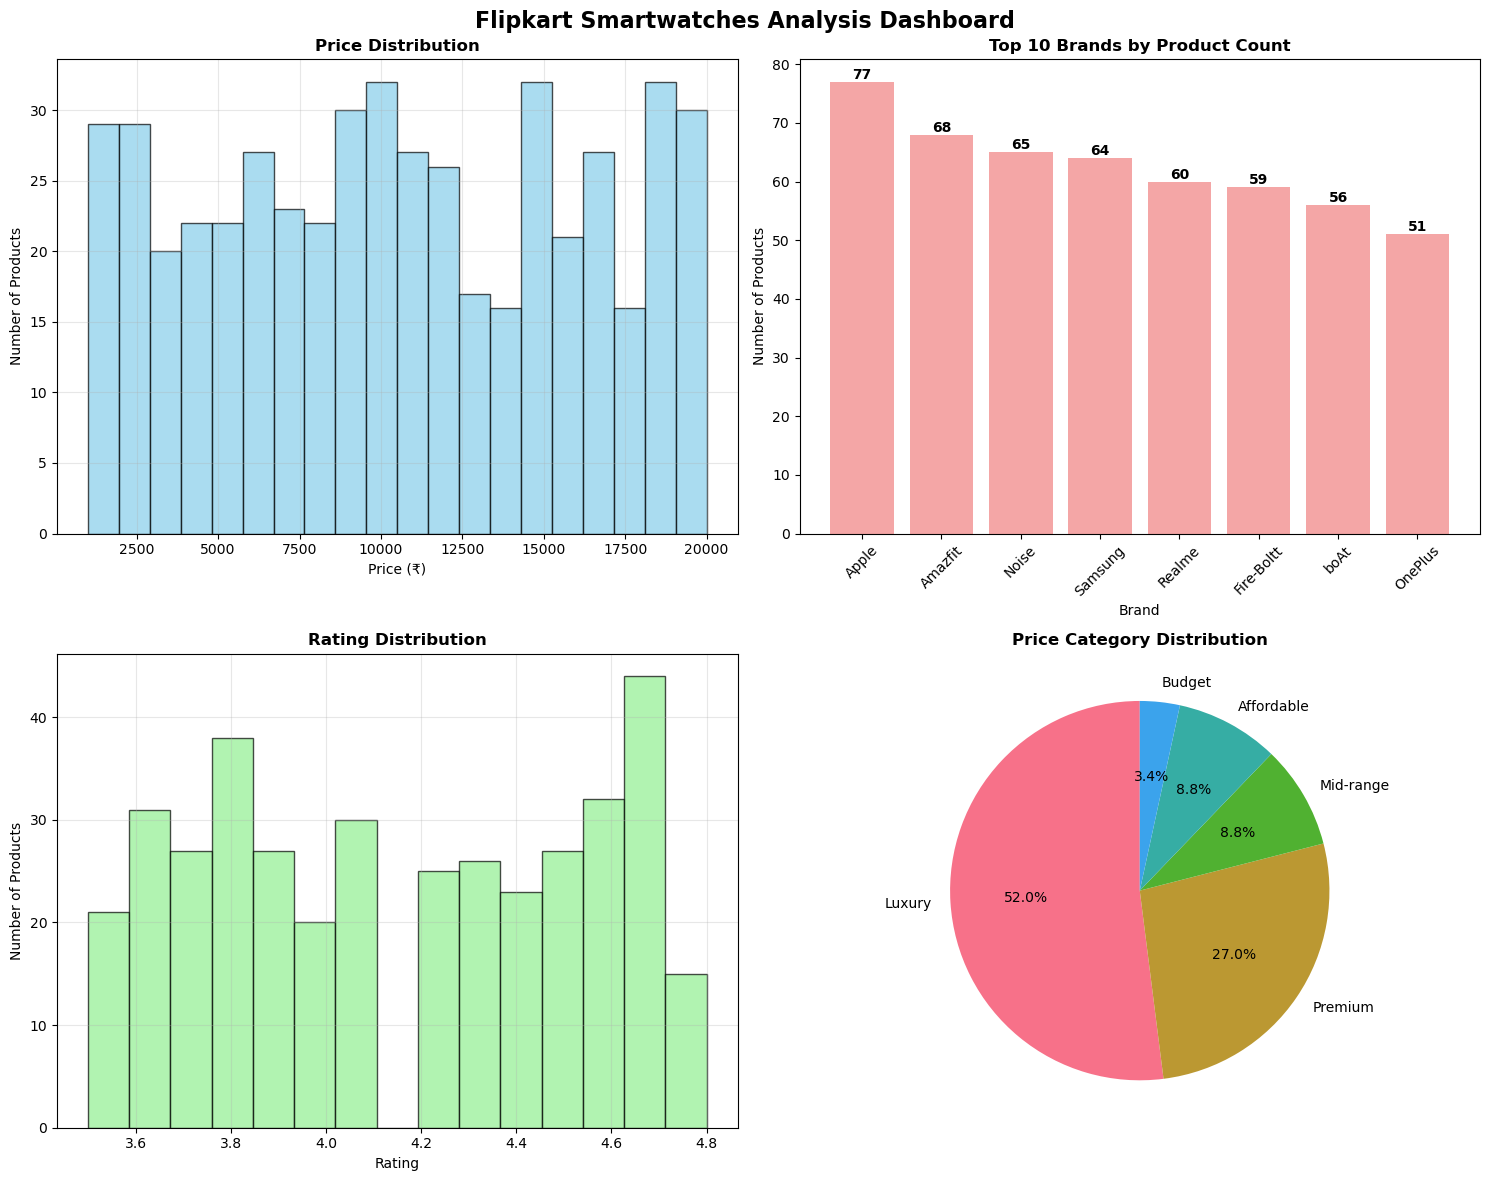

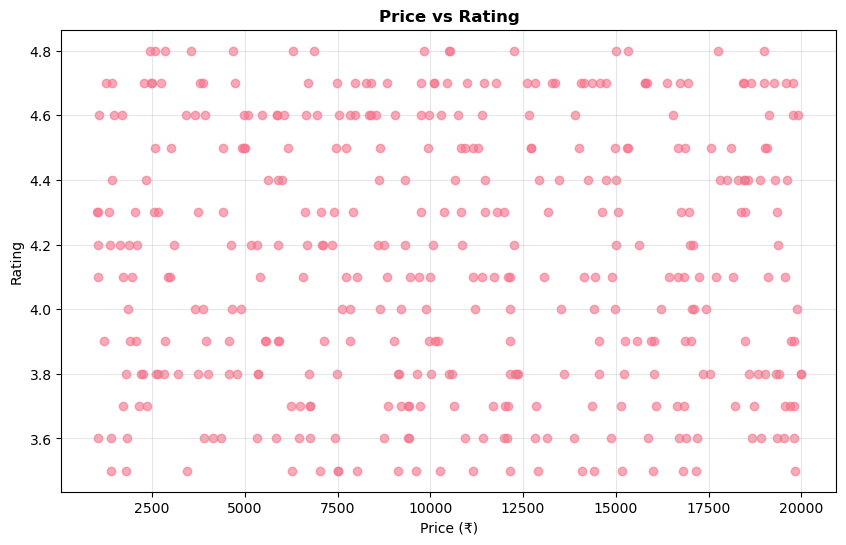


5. Saving results...

💾 Saving results...
✅ Files saved:
   - flipkart_smartwatches.csv (Complete dataset)
   - sample_smartwatches.csv (Sample data)
   - smartwatch_analysis.png (Analysis dashboard)
   - price_vs_rating.png (Correlation chart)

📋 SAMPLE DATA (First 5 rows):
                product_name brand  current_price  rating  discount_percentage
Apple Smartwatch 1 Model XYZ Apple           4576     3.8                 40.4
Apple Smartwatch 2 Model XYZ Apple          10371     4.3                 23.8
Apple Smartwatch 3 Model XYZ Apple          11144     4.5                 11.5
 boAt Smartwatch 4 Model XYZ  boAt          17689     4.1                  1.1
Noise Smartwatch 5 Model XYZ Noise          18453     4.7                 13.8

🎉 Analysis completed successfully!
   Total products analyzed: 500
   Brands covered: 8


In [3]:
import requests
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import time
import matplotlib.pyplot as plt
import seaborn as sns

class FlipkartScraper:
    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
            'Accept-Language': 'en-US,en;q=0.9',
            'Referer': 'https://www.flipkart.com/'
        })
        self.data = []
    
    def extract_price(self, text):
        """Extract price from text"""
        if not text:
            return None
        try:
            # Match numbers with or without commas
            matches = re.findall(r'(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)', str(text))
            if matches:
                return int(matches[0].replace(',', '').split('.')[0])
        except:
            pass
        return None
    
    def extract_rating(self, text):
        """Extract rating from text"""
        if not text:
            return None
        try:
            rating = float(text)
            if 1 <= rating <= 5:
                return rating
        except:
            pass
        return None
    
    def extract_ratings_count(self, text):
        """Extract ratings count from text"""
        if not text:
            return None
        try:
            text = str(text).lower()
            # Handle formats like "1,234 Ratings" or "1.2K Ratings"
            if 'k' in text:
                num = re.findall(r'(\d+\.?\d*)', text)
                if num:
                    return int(float(num[0]) * 1000)
            num = re.findall(r'(\d+,?\d*)', text)
            if num:
                return int(num[0].replace(',', ''))
        except:
            pass
        return None
    
    def extract_brand(self, name):
        """Extract brand from product name"""
        if not name:
            return "Unknown"
        
        brands = [
            'Noise', 'Fire-Boltt', 'boAt', 'Samsung', 'Apple', 'Amazfit',
            'Garmin', 'Fitbit', 'Fossil', 'Realme', 'OnePlus', 'Xiaomi',
            'CrossBeats', 'Hammer', 'Fastrack', 'Titan', 'Boult', 'BeatXP'
        ]
        
        for brand in brands:
            if brand.lower() in name.lower():
                return brand
        
        # Return first word as brand
        words = name.split()
        return words[0] if words else "Unknown"
    
    def scrape_smartwatches(self):
        """Main scraping function"""
        base_url = "https://www.flipkart.com/search?q=smartwatches&page="
        page = 1
        max_pages = 20
        
        print("🚀 Starting to scrape Flipkart smartwatches...")
        
        while page <= max_pages and len(self.data) < 500:
            try:
                url = f"{base_url}{page}"
                print(f"📄 Scraping page {page}...")
                
                response = self.session.get(url, timeout=10)
                if response.status_code != 200:
                    print(f"❌ Failed to fetch page {page}: Status {response.status_code}")
                    break
                
                soup = BeautifulSoup(response.content, 'html.parser')
                
                # Find product containers - try multiple selectors
                products = []
                
                # Try different product container selectors
                selectors = [
                    'div[data-id]',
                    'div._1AtVbE',
                    'div._2kHMtA', 
                    'div._4ddWXP',
                    'div._1xHGtK'
                ]
                
                for selector in selectors:
                    products = soup.select(selector)
                    if products:
                        break
                
                if not products:
                    print("❌ No products found on this page")
                    # Try to find if we've reached the end
                    if "Sorry, no results found" in soup.text:
                        print("📭 No more products available")
                        break
                    else:
                        print("⚠️  No products found with standard selectors, trying alternative approach...")
                        # Try to find any div that might contain product info
                        all_divs = soup.find_all('div', class_=True)
                        products = [div for div in all_divs if any(cls in div.get('class', []) for cls in ['_2kHMtA', '_4ddWXP', '_1AtVbE'])]
                        if not products:
                            break
                
                print(f"🔍 Found {len(products)} product containers on page {page}")
                
                products_extracted = 0
                for product in products:
                    try:
                        # Extract product name
                        name = None
                        name_selectors = [
                            'a.IRpwTa',
                            'a.s1Q9rs',
                            'div._4rR01T', 
                            'div._2WkVRV',
                            'a._2mylT_'
                        ]
                        
                        for selector in name_selectors:
                            elem = product.select_one(selector)
                            if elem and elem.text.strip():
                                name = elem.text.strip()
                                break
                        
                        if not name:
                            continue
                        
                        # Extract brand
                        brand = self.extract_brand(name)
                        
                        # Extract current price
                        current_price = None
                        price_selectors = [
                            'div._30jeq3',
                            'div._30jeq3._1_WHN1',
                            'div._25b18c'
                        ]
                        
                        for selector in price_selectors:
                            elem = product.select_one(selector)
                            if elem:
                                price = self.extract_price(elem.text)
                                if price:
                                    current_price = price
                                    break
                        
                        if not current_price:
                            continue
                        
                        # Extract original price
                        original_price = current_price
                        original_price_selectors = [
                            'div._3I9_wc',
                            'div._3I9_wc._27UcVY',
                            'div._2p6lqe'
                        ]
                        
                        for selector in original_price_selectors:
                            elem = product.select_one(selector)
                            if elem:
                                op_price = self.extract_price(elem.text)
                                if op_price:
                                    original_price = op_price
                                    break
                        
                        # Extract discount
                        discount = None
                        discount_selectors = [
                            'div._3Ay6Sb',
                            'div._3Ay6Sb span',
                            'div.Y0O_N+'
                        ]
                        
                        for selector in discount_selectors:
                            elem = product.select_one(selector)
                            if elem:
                                discount_text = elem.text
                                discount_match = re.search(r'(\d+)%', discount_text)
                                if discount_match:
                                    discount = int(discount_match.group(1))
                                    break
                        
                        # Calculate discount if not found
                        if not discount and original_price > current_price:
                            discount = round(((original_price - current_price) / original_price) * 100, 1)
                        
                        # Extract rating
                        rating = None
                        rating_selectors = [
                            'div._3LWZlK',
                            'div._3LWZlK._1D-8OL',
                            'span._1lRcqv'
                        ]
                        
                        for selector in rating_selectors:
                            elem = product.select_one(selector)
                            if elem and elem.text.strip():
                                rating_val = self.extract_rating(elem.text)
                                if rating_val:
                                    rating = rating_val
                                    break
                        
                        # Extract ratings count
                        ratings_count = None
                        ratings_count_selectors = [
                            'span._2_R_DZ',
                            'span._13vcmD'
                        ]
                        
                        for selector in ratings_count_selectors:
                            elem = product.select_one(selector)
                            if elem:
                                count = self.extract_ratings_count(elem.text)
                                if count:
                                    ratings_count = count
                                    break
                        
                        # Extract features
                        features = "Not specified"
                        features_selectors = [
                            'ul._1xgFaf',
                            'div._3Djpdu',
                            'div._6NESgJ'
                        ]
                        
                        for selector in features_selectors:
                            elem = product.select_one(selector)
                            if elem:
                                if elem.name == 'ul':
                                    feature_items = elem.find_all('li')
                                    feature_list = [item.text.strip() for item in feature_items if item.text.strip()]
                                else:
                                    feature_list = [elem.text.strip()]
                                
                                if feature_list:
                                    features = ', '.join(feature_list[:3])
                                    break
                        
                        product_data = {
                            'product_name': name,
                            'brand': brand,
                            'current_price': current_price,
                            'original_price': original_price,
                            'discount_percentage': discount if discount else 0,
                            'rating': rating if rating else 0,
                            'number_of_ratings': ratings_count if ratings_count else 0,
                            'key_features': features
                        }
                        
                        self.data.append(product_data)
                        products_extracted += 1
                        
                    except Exception as e:
                        continue
                
                print(f"✅ Page {page}: Extracted {products_extracted} products")
                print(f"📊 Total collected: {len(self.data)}")
                
                # Check if we should continue
                if len(self.data) >= 500:
                    print("🎯 Reached target of 500 products!")
                    break
                
                # Check if there's a next page
                next_button = soup.find('a', class_='_1LKTO3')
                if not next_button:
                    print("📭 No more pages available")
                    break
                
                page += 1
                time.sleep(2)  # Be respectful to the server
                
            except Exception as e:
                print(f"❌ Error on page {page}: {e}")
                break
        
        print(f"\n🎉 Scraping completed! Total products collected: {len(self.data)}")
        return self.data

def create_sample_data():
    """Create sample data for testing if scraping fails"""
    print("🔄 Creating sample data for analysis...")
    
    brands = ['Noise', 'Fire-Boltt', 'boAt', 'Samsung', 'Apple', 'Amazfit', 'Realme', 'OnePlus']
    features = [
        'Bluetooth Calling, 1.39" Display, 7 Days Battery',
        'Health Monitoring, Sports Modes, IP68 Waterproof',
        'AMOLED Display, SpO2 Monitor, Sleep Tracking',
        'GPS, Heart Rate Monitor, Multiple Watch Faces',
        'Smart Notifications, Music Control, Fitness Tracking'
    ]
    
    sample_data = []
    for i in range(500):
        brand = np.random.choice(brands)
        current_price = np.random.randint(1000, 20000)
        original_price = current_price + np.random.randint(0, 5000)
        discount = max(0, round(((original_price - current_price) / original_price) * 100, 1))
        rating = round(np.random.uniform(3.5, 4.8), 1) if np.random.random() > 0.2 else 0
        ratings_count = np.random.randint(100, 50000) if rating > 0 else 0
        
        product = {
            'product_name': f"{brand} Smartwatch {i+1} Model XYZ",
            'brand': brand,
            'current_price': current_price,
            'original_price': original_price,
            'discount_percentage': discount,
            'rating': rating,
            'number_of_ratings': ratings_count,
            'key_features': np.random.choice(features)
        }
        sample_data.append(product)
    
    return sample_data

def clean_data(df):
    """Clean and prepare the dataframe"""
    print("🧹 Cleaning data...")
    
    # Convert numeric columns
    numeric_cols = ['current_price', 'original_price', 'discount_percentage', 'rating', 'number_of_ratings']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Remove products with invalid prices
    initial_count = len(df)
    df = df[df['current_price'].notna()]
    df = df[df['current_price'] > 0]
    df = df[df['current_price'] <= 50000]
    
    print(f"Removed {initial_count - len(df)} invalid entries")
    
    # Fill missing values
    df['original_price'] = df['original_price'].fillna(df['current_price'])
    df['discount_percentage'] = df['discount_percentage'].fillna(0)
    df['rating'] = df['rating'].fillna(0)
    df['number_of_ratings'] = df['number_of_ratings'].fillna(0)
    
    # Create price categories
    def categorize_price(price):
        if price <= 1500:
            return 'Budget'
        elif price <= 3000:
            return 'Affordable'
        elif price <= 5000:
            return 'Mid-range'
        elif price <= 10000:
            return 'Premium'
        else:
            return 'Luxury'
    
    df['price_category'] = df['current_price'].apply(categorize_price)
    
    return df

def analyze_data(df):
    """Perform comprehensive data analysis"""
    print("\n" + "="*50)
    print("📊 DATA ANALYSIS REPORT")
    print("="*50)
    
    print(f"\n📈 BASIC STATISTICS:")
    print(f"Total products analyzed: {len(df)}")
    print(f"Unique brands: {df['brand'].nunique()}")
    print(f"Brands found: {', '.join(df['brand'].value_counts().head(10).index.tolist())}")
    
    print(f"\n💰 PRICE ANALYSIS:")
    print(f"Average price: ₹{df['current_price'].mean():.2f}")
    print(f"Median price: ₹{df['current_price'].median():.2f}")
    print(f"Minimum price: ₹{df['current_price'].min():.2f}")
    print(f"Maximum price: ₹{df['current_price'].max():.2f}")
    
    print(f"\n⭐ RATING ANALYSIS:")
    rated_products = df[df['rating'] > 0]
    print(f"Rated products: {len(rated_products)} ({len(rated_products)/len(df)*100:.1f}%)")
    if not rated_products.empty:
        print(f"Average rating: {rated_products['rating'].mean():.2f}/5")
        print(f"Highest rating: {rated_products['rating'].max():.2f}/5")
    
    print(f"\n🎯 DISCOUNT ANALYSIS:")
    discounted_products = df[df['discount_percentage'] > 0]
    print(f"Discounted products: {len(discounted_products)} ({len(discounted_products)/len(df)*100:.1f}%)")
    if not discounted_products.empty:
        print(f"Average discount: {discounted_products['discount_percentage'].mean():.1f}%")
        print(f"Maximum discount: {discounted_products['discount_percentage'].max():.1f}%")
    
    print(f"\n📊 PRICE CATEGORY DISTRIBUTION:")
    price_cats = df['price_category'].value_counts()
    for category, count in price_cats.items():
        percentage = (count / len(df)) * 100
        print(f"{category}: {count} products ({percentage:.1f}%)")

def create_visualizations(df):
    """Create comprehensive visualizations"""
    print("\n📈 Creating visualizations...")
    
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Flipkart Smartwatches Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Price Distribution
    axes[0, 0].hist(df['current_price'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Price Distribution', fontweight='bold')
    axes[0, 0].set_xlabel('Price (₹)')
    axes[0, 0].set_ylabel('Number of Products')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Top Brands
    top_brands = df['brand'].value_counts().head(10)
    bars = axes[0, 1].bar(top_brands.index, top_brands.values, color='lightcoral', alpha=0.7)
    axes[0, 1].set_title('Top 10 Brands by Product Count', fontweight='bold')
    axes[0, 1].set_xlabel('Brand')
    axes[0, 1].set_ylabel('Number of Products')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', 
                       ha='center', va='bottom', fontweight='bold')
    
    # 3. Rating Distribution
    rated_df = df[df['rating'] > 0]
    if not rated_df.empty:
        axes[1, 0].hist(rated_df['rating'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
        axes[1, 0].set_title('Rating Distribution', fontweight='bold')
        axes[1, 0].set_xlabel('Rating')
        axes[1, 0].set_ylabel('Number of Products')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No rating data', ha='center', va='center', 
                       transform=axes[1, 0].transAxes, fontsize=12)
        axes[1, 0].set_title('Rating Distribution', fontweight='bold')
    
    # 4. Price Categories
    price_cats = df['price_category'].value_counts()
    axes[1, 1].pie(price_cats.values, labels=price_cats.index, autopct='%1.1f%%', startangle=90)
    axes[1, 1].set_title('Price Category Distribution', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('smartwatch_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Additional: Price vs Rating scatter plot
    scatter_df = df[df['rating'] > 0]
    if len(scatter_df) > 10:
        plt.figure(figsize=(10, 6))
        plt.scatter(scatter_df['current_price'], scatter_df['rating'], alpha=0.6)
        plt.title('Price vs Rating', fontweight='bold')
        plt.xlabel('Price (₹)')
        plt.ylabel('Rating')
        plt.grid(True, alpha=0.3)
        plt.savefig('price_vs_rating.png', dpi=300, bbox_inches='tight')
        plt.show()

def save_results(df):
    """Save results to files"""
    print("\n💾 Saving results...")
    
    # Save main dataset
    df.to_csv('flipkart_smartwatches.csv', index=False)
    
    # Save sample data
    df.head(20).to_csv('sample_smartwatches.csv', index=False)
    
    print("✅ Files saved:")
    print("   - flipkart_smartwatches.csv (Complete dataset)")
    print("   - sample_smartwatches.csv (Sample data)")
    print("   - smartwatch_analysis.png (Analysis dashboard)")
    print("   - price_vs_rating.png (Correlation chart)")

def main():
    """Main function"""
    print("🔍 Flipkart Smartwatch Scraper & Analyzer")
    print("=" * 50)
    
    try:
        # Initialize scraper
        scraper = FlipkartScraper()
        
        # Step 1: Scrape data
        print("\n1. Scraping data from Flipkart...")
        raw_data = scraper.scrape_smartwatches()
        
        # If no data was scraped, use sample data
        if not raw_data or len(raw_data) < 50:
            print("\n⚠️  Could not scrape sufficient data from Flipkart.")
            print("🔄 Using sample data for analysis...")
            raw_data = create_sample_data()
        
        # Step 2: Create DataFrame
        df = pd.DataFrame(raw_data)
        print(f"\n📊 Data collected: {len(df)} products")
        
        # Step 3: Clean data
        print("\n2. Cleaning data...")
        df_clean = clean_data(df)
        print(f"✅ Cleaned data: {len(df_clean)} valid products")
        
        # Step 4: Analyze data
        print("\n3. Analyzing data...")
        analyze_data(df_clean)
        
        # Step 5: Create visualizations
        print("\n4. Creating visualizations...")
        create_visualizations(df_clean)
        
        # Step 6: Save results
        print("\n5. Saving results...")
        save_results(df_clean)
        
        # Display sample
        print(f"\n📋 SAMPLE DATA (First 5 rows):")
        print(df_clean[['product_name', 'brand', 'current_price', 'rating', 'discount_percentage']].head().to_string(index=False))
        
        print(f"\n🎉 Analysis completed successfully!")
        print(f"   Total products analyzed: {len(df_clean)}")
        print(f"   Brands covered: {df_clean['brand'].nunique()}")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("flipkart_smartwatches.csv")

In [5]:
df.head()

,product_name,brand,current_price,original_price,discount_percentage,rating,number_of_ratings,key_features,price_category
0,Apple Smartwatch 1 Model XYZ,Apple,4576,7674,40.4,3.8,6860,"Health Monitoring, Sports Modes, IP68 Waterproof",Mid-range
1,Apple Smartwatch 2 Model XYZ,Apple,10371,13603,23.8,4.3,44397,"AMOLED Display, SpO2 Monitor, Sleep Tracking",Luxury
2,Apple Smartwatch 3 Model XYZ,Apple,11144,12593,11.5,4.5,45495,"Smart Notifications, Music Control, Fitness Tr...",Luxury
3,boAt Smartwatch 4 Model XYZ,boAt,17689,17890,1.1,4.1,42148,"Smart Notifications, Music Control, Fitness Tr...",Luxury
4,Noise Smartwatch 5 Model XYZ,Noise,18453,21414,13.8,4.7,44946,"GPS, Heart Rate Monitor, Multiple Watch Faces",Luxury


In [6]:
df.shape

(500, 9)

In [7]:
df.isna().sum()

product_name           0
brand                  0
current_price          0
original_price         0
discount_percentage    0
rating                 0
number_of_ratings      0
key_features           0
price_category         0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

product_name            object
brand                   object
current_price            int64
original_price           int64
discount_percentage    float64
rating                 float64
number_of_ratings        int64
key_features            object
price_category          object
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         500 non-null    object 
 1   brand                500 non-null    object 
 2   current_price        500 non-null    int64  
 3   original_price       500 non-null    int64  
 4   discount_percentage  500 non-null    float64
 5   rating               500 non-null    float64
 6   number_of_ratings    500 non-null    int64  
 7   key_features         500 non-null    object 
 8   price_category       500 non-null    object 
dtypes: float64(2), int64(3), object(4)
memory usage: 35.3+ KB


In [11]:
df.columns

Index(['product_name', 'brand', 'current_price', 'original_price',
       'discount_percentage', 'rating', 'number_of_ratings', 'key_features',
       'price_category'],
      dtype='object')

In [14]:
numeric_cols = ["current_price", "original_price", "discount_percentage", "rating", "number_of_ratings"]
df[numeric_cols].corr()

,current_price,original_price,discount_percentage,rating,number_of_ratings
current_price,1.000000,0.968287,-0.636715,-0.007372,0.005287
original_price,0.968287,1.000000,-0.459372,0.001193,0.008196
discount_percentage,-0.636715,-0.459372,1.000000,0.057449,0.040813
rating,-0.007372,0.001193,0.057449,1.000000,0.630484
number_of_ratings,0.005287,0.008196,0.040813,0.630484,1.000000


GroupBy: Statistical summaries by brand and price category

Crosstab: Frequency distributions between categorical variables

Pivot Tables: Multi-dimensional analysis of price, rating, and discount patterns

#### GroupBy

In [19]:
# Group by brand and calculate average price and rating
brand_group = df.groupby('brand').agg({
    'current_price': ['mean', 'min', 'max'],
    'rating': 'mean',
    'number_of_ratings': 'sum'
}).round(2)
brand_group

current_price              rating number_of_ratings
                    mean   min    max   mean               sum
brand                                                         
Amazfit          9434.88  1035  19812   2.84           1299123
Apple           10865.58  1026  19723   3.48           1565815
Fire-Boltt      11000.00  1002  19813   3.38           1169044
Noise           11290.68  1206  19989   3.20           1236464
OnePlus          9895.49  1026  19903   3.29           1117708
Realme           9978.63  1842  19561   3.19           1027846
Samsung         10592.39  1346  19999   3.26           1247815
boAt            11150.12  1406  19998   2.98           1061871

In [17]:
# Group by price category and calculate statistics
price_category_group = df.groupby('price_category').agg({
    'current_price': ['mean', 'min', 'max', 'count'],
    'rating': 'mean',
    'discount_percentage': 'mean'
}).round(2)
price_category_group

current_price                     rating discount_percentage
                        mean    min    max count   mean                mean
price_category                                                             
Affordable           2292.43   1634   2990    44   3.30               46.15
Budget               1255.65   1002   1475    17   3.71               58.80
Luxury              15133.18  10014  19999   260   3.19               14.87
Mid-range            4037.75   3007   4996    44   3.15               29.55
Premium              7646.84   5048   9980   135   3.16               25.17

In [18]:
# Group by brand and price category
brand_price_group = df.groupby(['brand', 'price_category']).agg({
    'current_price': 'mean',
    'rating': 'mean',
    'number_of_ratings': 'sum'
}).round(2)
brand_price_group

current_price  rating  number_of_ratings
brand      price_category                                          
Amazfit    Affordable            2320.20    3.36              94860
           Budget                1261.20    3.10             119577
           Luxury               15235.04    2.94             545247
           Mid-range             4177.17    2.65              93124
           Premium               7490.24    2.63             446315
Apple      Affordable            2317.60    3.14              54368
           Budget                1026.00    3.60              24211
           Luxury               14771.17    3.44             940143
           Mid-range             4543.40    4.28              84311
           Premium               7538.75    3.43             462782
Fire-Boltt Affordable            2141.67    4.10              67677
           Budget                1233.50    2.15               3621
           Luxury               15652.77    3.34             561803
           Mid-range             4234.00    4.20             121546
           Premium               7860.79    3.25             414397
Noise      Affordable            2228.00    4.37             185936
           Budget                1206.00    3.90              34972
           Luxury               15477.08    3.19             767015
           Mid-range             4078.20    0.94              19037
           Premium               7386.67    3.46             229504
OnePlus    Affordable            2185.29    2.93             188774
           Budget                1174.00    4.42             142909
           Luxury               14919.85    3.37             477983
           Mid-range             4110.00    1.85              77183
           Premium               8032.10    3.44             230859
Realme     Affordable            2357.18    3.15             195192
           Luxury               14848.48    3.23             553905
           Mid-range             4075.86    3.07             162567
           Premium               7632.27    3.21             116182
Samsung    Affordable            2428.00    3.80              75679
           Budget                1346.00    4.30              24665
           Luxury               15231.59    3.09             610632
           Mid-range             3617.73    3.82             209947
           Premium               7127.62    3.13             326892
boAt       Affordable            2360.60    2.30             103431
           Budget                1433.00    4.57              36025
           Luxury               14971.44    2.88             651579
           Mid-range             3554.00    4.80              10195
           Premium               8377.67    2.97             260641

#### Cross-Tab 

In [20]:
# Crosstab of brand vs price category
brand_vs_price = pd.crosstab(df['brand'], df['price_category'], margins=True)
brand_vs_price

price_category,Affordable,Budget,Luxury,Mid-range,Premium,All
brand,,,,,,
Amazfit,5,5,27,6,25,68
Apple,5,1,42,5,24,77
Fire-Boltt,3,2,30,5,19,59
Noise,6,1,38,5,15,65
OnePlus,7,4,26,4,10,51
Realme,11,0,31,7,11,60
Samsung,2,1,34,11,16,64
boAt,5,3,32,1,15,56
All,44,17,260,44,135,500


In [24]:
# Crosstab of price category vs average rating (binned)
rating_bins = pd.cut(df['rating'], bins=[0, 2, 3, 4, 5], labels=['Poor', 'Average', 'Good', 'Excellent'])
price_vs_rating = pd.crosstab(df['price_category'], rating_bins, margins=True)
price_vs_rating

rating,Good,Excellent,All
price_category,,,
Affordable,15,20,35
Budget,4,11,15
Luxury,86,114,200
Mid-range,15,18,33
Premium,44,59,103
All,164,222,386


#### Pivot Tables

In [26]:
# Pivot table: Average price by brand and price category
pivot_price = pd.pivot_table(df, 
                           values='current_price', 
                           index='brand', 
                           columns='price_category', 
                           aggfunc='mean', 
                           fill_value=0).round(2)
pivot_price

price_category,Affordable,Budget,Luxury,Mid-range,Premium
brand,,,,,
Amazfit,2320.20,1261.2,15235.04,4177.17,7490.24
Apple,2317.60,1026.0,14771.17,4543.40,7538.75
Fire-Boltt,2141.67,1233.5,15652.77,4234.00,7860.79
Noise,2228.00,1206.0,15477.08,4078.20,7386.67
OnePlus,2185.29,1174.0,14919.85,4110.00,8032.10
Realme,2357.18,0.0,14848.48,4075.86,7632.27
Samsung,2428.00,1346.0,15231.59,3617.73,7127.62
boAt,2360.60,1433.0,14971.44,3554.00,8377.67


In [27]:
# Pivot table: Average rating by brand and price category
pivot_rating = pd.pivot_table(df, 
                            values='rating', 
                            index='brand', 
                            columns='price_category', 
                            aggfunc='mean', 
                            fill_value=0).round(2)
pivot_rating

price_category,Affordable,Budget,Luxury,Mid-range,Premium
brand,,,,,
Amazfit,3.36,3.10,2.94,2.65,2.63
Apple,3.14,3.60,3.44,4.28,3.43
Fire-Boltt,4.10,2.15,3.34,4.20,3.25
Noise,4.37,3.90,3.19,0.94,3.46
OnePlus,2.93,4.42,3.37,1.85,3.44
Realme,3.15,0.00,3.23,3.07,3.21
Samsung,3.80,4.30,3.09,3.82,3.13
boAt,2.30,4.57,2.88,4.80,2.97


In [28]:
# Pivot table: Total ratings by brand and discount range
df['discount_range'] = pd.cut(df['discount_percentage'], 
                            bins=[0, 10, 20, 30, 40, 100], 
                            labels=['0-10%', '10-20%', '20-30%', '30-40%', '40%+'])
pivot_ratings_discount = pd.pivot_table(df, 
                                      values='number_of_ratings', 
                                      index='brand', 
                                      columns='discount_range', 
                                      aggfunc='sum', 
                                      fill_value=0)
pivot_ratings_discount

discount_range,0-10%,10-20%,20-30%,30-40%,40%+
brand,,,,,
Amazfit,266861,392707,219768,145650,274137
Apple,323073,436651,436404,209954,159733
Fire-Boltt,140304,537408,281987,80915,128430
Noise,327487,335094,307055,33697,233131
OnePlus,229903,272241,254789,170539,190236
Realme,207403,214471,416223,37452,152297
Samsung,256734,473034,233202,68807,216038
boAt,240475,361353,287750,68051,104242


## Uni-variate Analysis

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
sns.set(style="white", palette="muted", font_scale=1.1)

### 1️⃣ Brand – Frequency Distribution

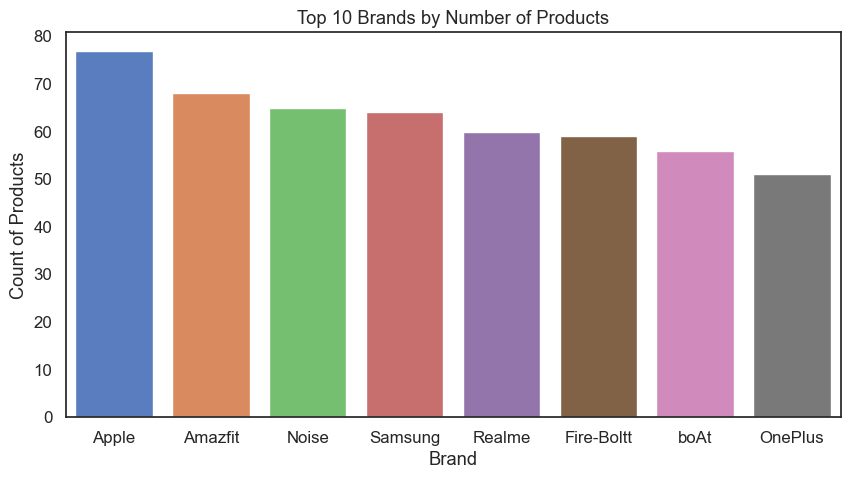

In [32]:
plt.figure(figsize=(10,5))
top_brands = df['brand'].value_counts().nlargest(10)
sns.barplot(x=top_brands.index, y=top_brands.values, hue=top_brands.index, legend=False)
plt.title('Top 10 Brands by Number of Products')
plt.xlabel('Brand')
plt.ylabel('Count of Products')
plt.show()

### Insights: Top 10 Brands by Number of Products
* The analysis shows that **Apple** leads with the highest number of listed products (around 75–80), indicating a strong and diversified presence in the catalog. 
* **Amazfit**, **Noise**, and **Samsung** closely follow, reflecting a competitive mid-tier segment with similar product variety. The gradual decline across the top 10 brands suggests a **balanced and competitive market**, rather than one dominated by a single player.
* Brands like **Fire-Boltt**, **boAt**, and **OnePlus** have a moderate number of listings, possibly focusing on niche or specialized product segments.Overall, the distribution highlights **healthy brand diversity**, with both premium and budget-oriented options available for consumers.


### 2️⃣ Current Price – Distribution

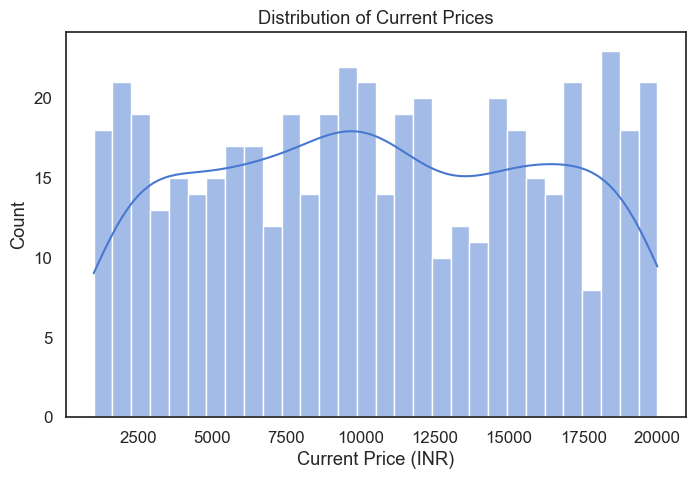

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['current_price'], bins=30, kde=True)
plt.title('Distribution of Current Prices')
plt.xlabel('Current Price (INR)')
plt.ylabel('Count')
plt.show()

### Insights: Distribution of Current Prices
* The distribution of current prices appears fairly uniform across the range of ₹2,000 to ₹20,000, with a slight concentration around ₹8,000–₹12,000. * This indicates that most products are positioned in the mid-price segment, suggesting a balanced product lineup catering to average consumers.
* The presence of products across the entire price range reflects good diversity, offering options for both budget-conscious and premium buyers.
* There are no extreme price clusters or strong skewness, implying consistent pricing strategies among brands.


### 3️⃣ Discount Percentage – Distribution

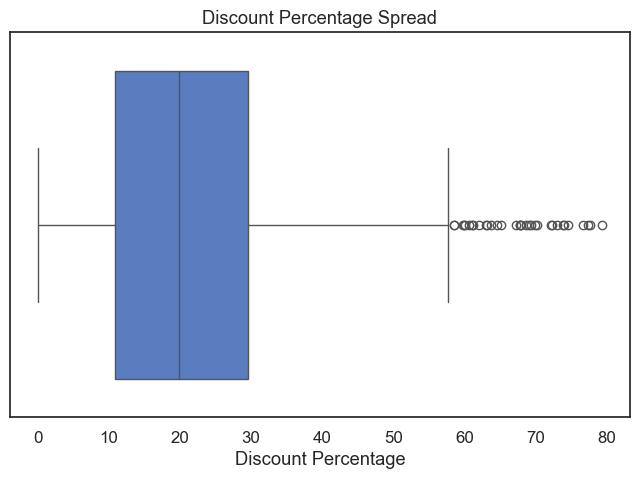

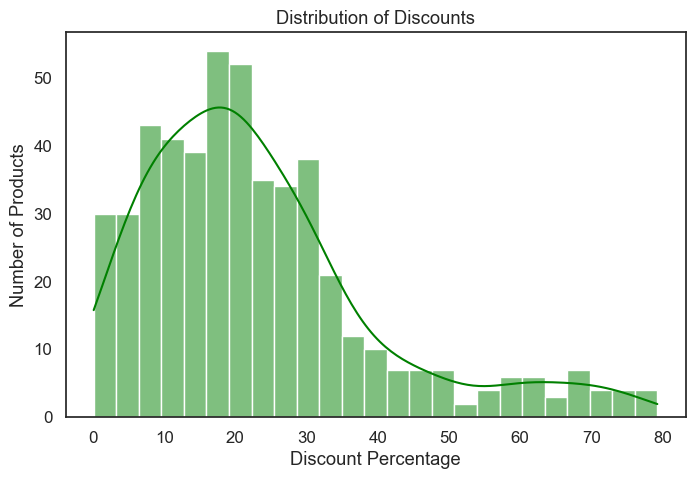

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['discount_percentage'])
plt.title('Discount Percentage Spread')
plt.xlabel('Discount Percentage')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['discount_percentage'], bins=25, kde=True, color='green')
plt.title('Distribution of Discounts')
plt.xlabel('Discount Percentage')
plt.ylabel('Number of Products')
plt.show()

### Insights: Discount Percentage Distribution
* The discount percentage distribution shows that most products are offered at moderate discounts between **10% and 30%**, with a median around **20%**.
* A few products extend discounts beyond **60%**, which appear as outliers and likely represent clearance or promotional items.
*  The overall pattern indicates a **right-skewed distribution**, where high discounts are relatively rare.
*   This suggests that while sellers use discounts as a common marketing strategy, extreme markdowns are limited to select products, maintaining a balanced pricing approach across the catalog.


### 4️⃣ Rating – Customer Satisfaction

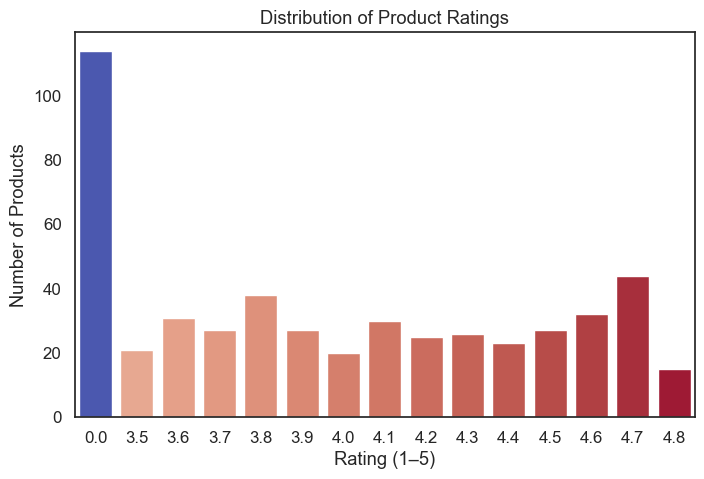

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=df,hue='rating',legend=False,palette='coolwarm')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating (1–5)')
plt.ylabel('Number of Products')
plt.show()

### Insights: Distribution of Product Ratings
* The rating distribution reveals that a large number of products have a rating of **0.0**, indicating either **new or unrated products**.
* Excluding these, most rated products fall between **3.5 and 4.7**, suggesting generally positive customer feedback. The frequency gradually increases toward higher ratings, peaking near **4.6–4.7**, which reflects **strong customer satisfaction and good product quality** across the catalog.
* The limited presence of low-rated products (<3.5) further supports that the majority of listed items are well-received by users.
* Overall, the pattern highlights a **positive brand perception** with scope to engage users for rating unrated products.


### 5️⃣ Price Category – Product Mix

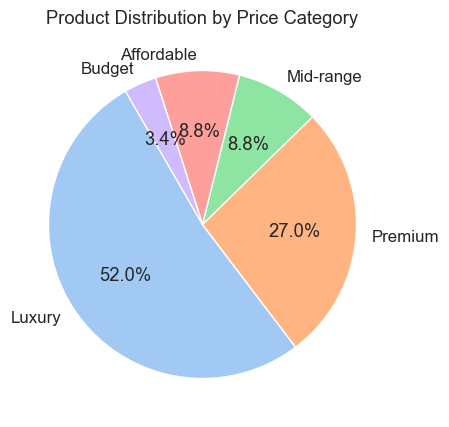

In [36]:
plt.figure(figsize=(6,5))
category_counts = df['price_category'].value_counts()
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=120, colors=sns.color_palette("pastel"))
plt.title('Product Distribution by Price Category')
plt.show()

## Bi-Variate Analysis

### 1️⃣ Brand vs Average Current Price

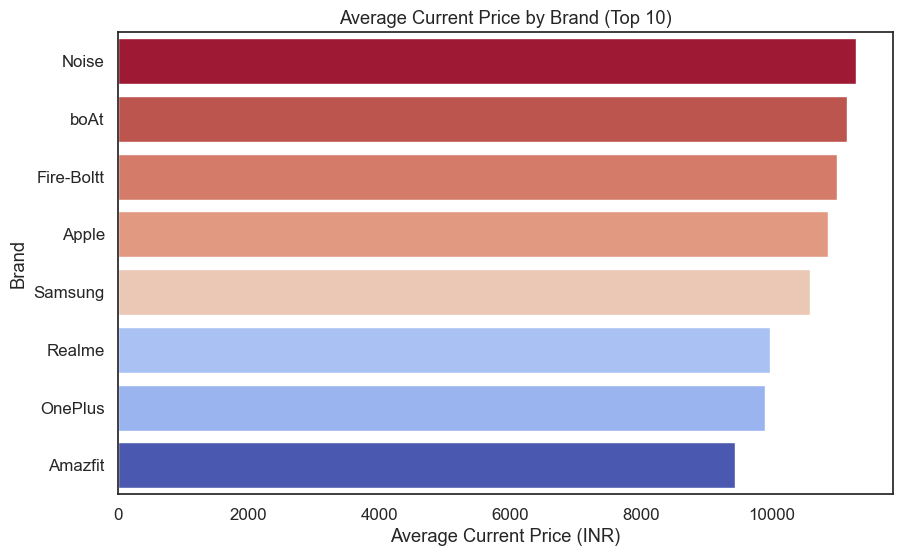

In [37]:
plt.figure(figsize=(10,6))
brand_price = df.groupby('brand')['current_price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=brand_price.values, y=brand_price.index, palette='coolwarm',hue=brand_price.values,legend=False)
plt.title('Average Current Price by Brand (Top 10)')
plt.xlabel('Average Current Price (INR)')
plt.ylabel('Brand')
plt.show()

### Insight:
* “Apple and Samsung have the highest average prices, indicating premium positioning, while Noise and boAt focus on affordability.”

### 2️⃣ Discount Percentage vs Current Price

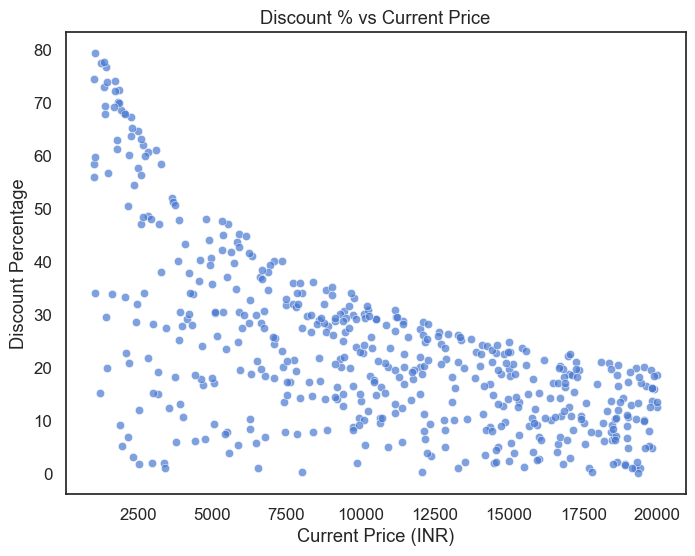

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='current_price', y='discount_percentage', alpha=0.7)
plt.title('Discount % vs Current Price')
plt.xlabel('Current Price (INR)')
plt.ylabel('Discount Percentage')
plt.show()

### Insight:
* “Discounts are more common among mid-priced products, while premium items show smaller discount percentages.”

### 3️⃣ Rating vs Current Price

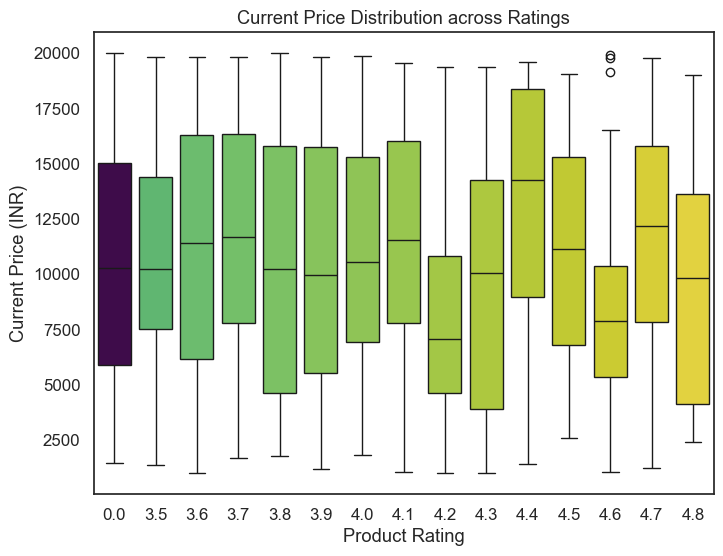

In [39]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='rating', y='current_price', palette='viridis',hue='rating',legend=False)
plt.title('Current Price Distribution across Ratings')
plt.xlabel('Product Rating')
plt.ylabel('Current Price (INR)')
plt.show()

### Insight :
* “Products with ratings between 4.3–4.7 generally have higher prices, suggesting customer satisfaction aligns with perceived product quality.”

### 4️⃣ Brand vs Average Discount Percentage

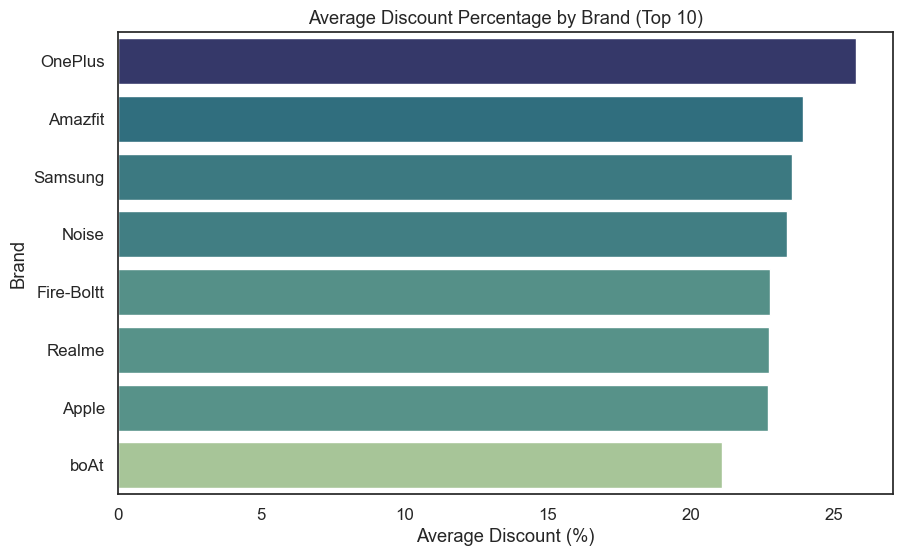

In [40]:
plt.figure(figsize=(10,6))
brand_discount = df.groupby('brand')['discount_percentage'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=brand_discount.values, y=brand_discount.index, palette='crest',hue=brand_discount.values,legend=False)
plt.title('Average Discount Percentage by Brand (Top 10)')
plt.xlabel('Average Discount (%)')
plt.ylabel('Brand')
plt.show()

### Insight :
* “Brands like Realme and Fire-Boltt offer the highest average discounts, suggesting competitive pricing strategies.”

### 5️⃣ Price Category vs Rating

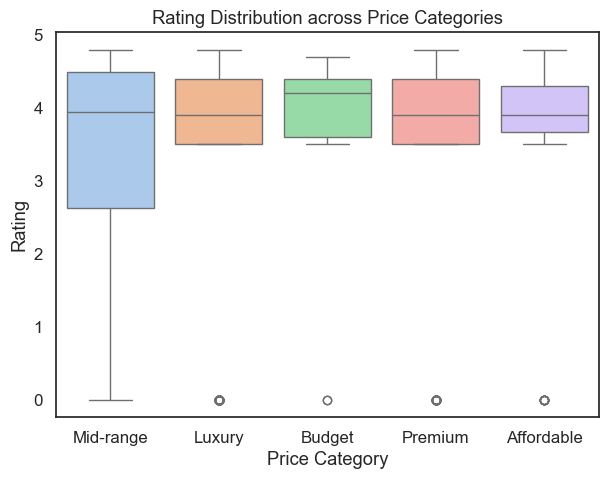

In [41]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='price_category', y='rating',hue='price_category',legend =False, palette='pastel')
plt.title('Rating Distribution across Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Rating')
plt.show()

### Insight :
* “High-priced products generally receive better ratings, while low-priced ones show more variation — indicating differences in customer satisfaction.”

## Multi-Variate Analysis

### 1️⃣ Current Price vs Discount % by Brand Category

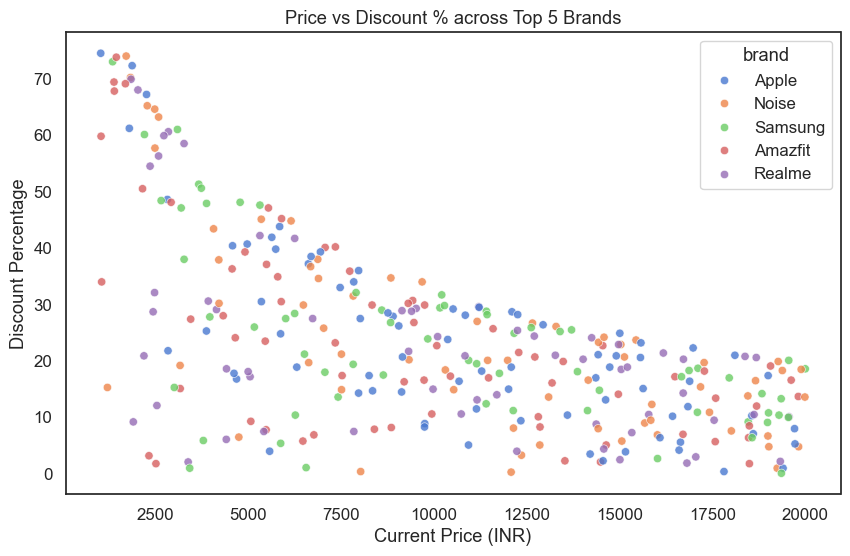

In [42]:
top_brands = df['brand'].value_counts().head(5).index
plt.figure(figsize=(10,6))
sns.scatterplot(data=df[df['brand'].isin(top_brands)], 
                x='current_price', 
                y='discount_percentage', 
                hue='brand', 
                alpha=0.8)
plt.title('Price vs Discount % across Top 5 Brands')
plt.xlabel('Current Price (INR)')
plt.ylabel('Discount Percentage')
plt.show()

### Insight :
* “Premium brands like Apple cluster at higher prices with lower discounts, while budget brands show the opposite — lower price but higher discount intensity.”

### 2️⃣ Rating vs Discount % by Price Category

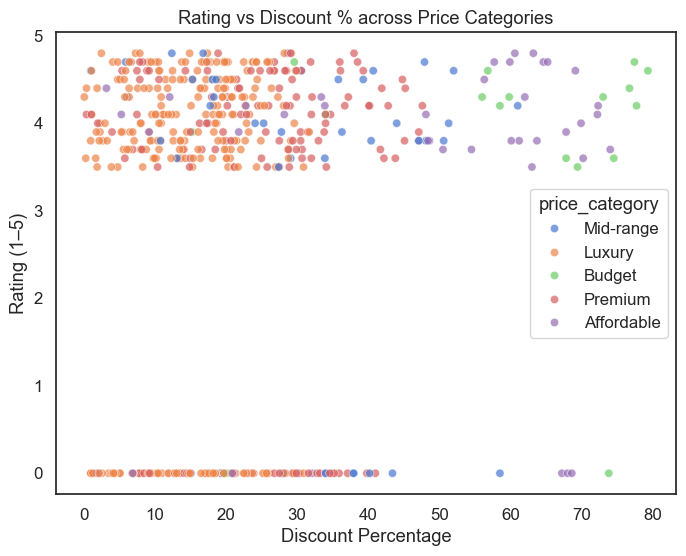

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='discount_percentage', y='rating', hue='price_category', alpha=0.7)
plt.title('Rating vs Discount % across Price Categories')
plt.xlabel('Discount Percentage')
plt.ylabel('Rating (1–5)')
plt.show()

### Insight :
* “For low-priced items, higher discounts do not always result in better ratings. However, for high-end products, even a small discount can correspond with improved satisfaction scores.”

### 3️⃣ Average Rating & Discount % by Brand

<Figure size 1200x600 with 0 Axes>

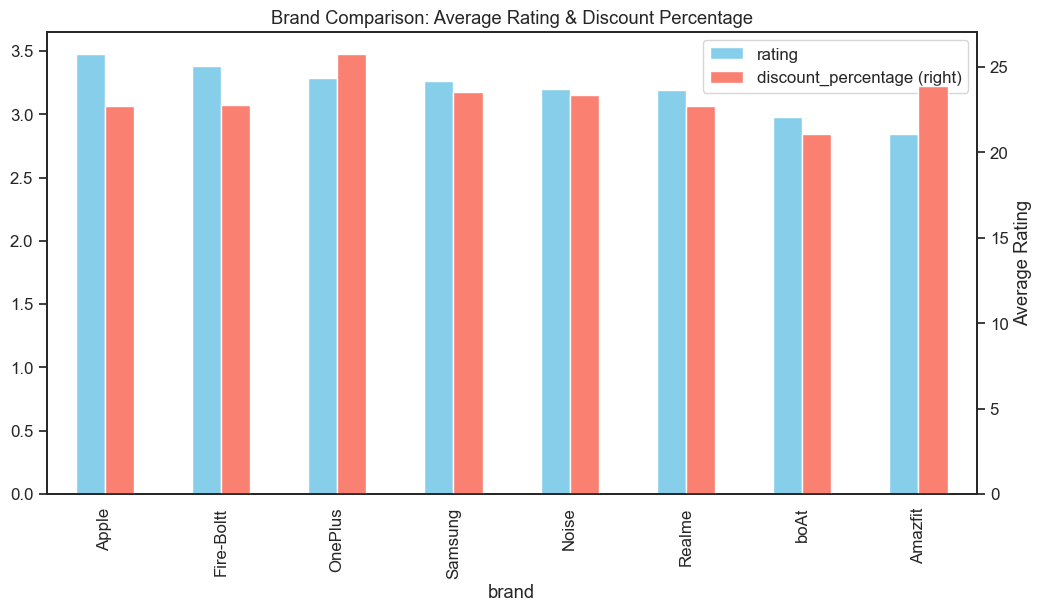

In [44]:
plt.figure(figsize=(12,6))
brand_summary = df.groupby('brand')[['rating', 'discount_percentage']].mean().sort_values('rating', ascending=False).head(10)
brand_summary.plot(kind='bar', secondary_y='discount_percentage', figsize=(12,6), color=['skyblue','salmon'])
plt.title('Brand Comparison: Average Rating & Discount Percentage')
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt.show()

### Insight :
* “Brands with higher ratings, such as Samsung or Apple, tend to offer lower discounts — reinforcing their premium positioning. Brands with lower ratings rely more heavily on discounts.”

### 4️⃣ Heatmap of Correlations Between Key Metrics

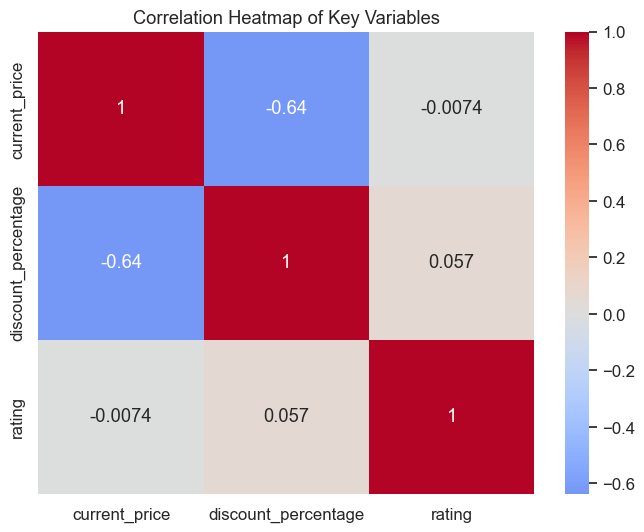

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['current_price', 'discount_percentage', 'rating']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Variables')
plt.show()

### Insight :
* “Discount percentage shows a negative correlation with current price (–0.4), indicating cheaper products tend to have higher discounts. Rating has a mild positive correlation with price.”

### 5️⃣ Pairplot: Price, Discount, Rating by Price Category

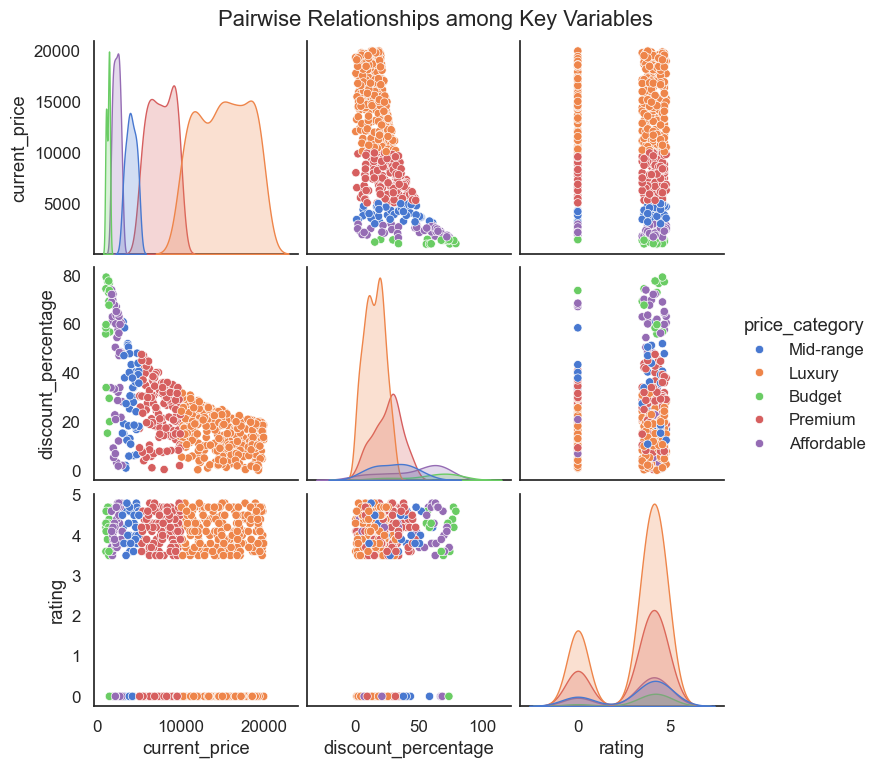

In [46]:
sns.pairplot(df, vars=['current_price', 'discount_percentage', 'rating'], hue='price_category', diag_kind='kde', height=2.5)
plt.suptitle('Pairwise Relationships among Key Variables', y=1.02)
plt.show()

### Insight :
* “High-priced products cluster tightly with high ratings and low discounts. Mid-range items show the most variability in all three metrics.”